# Aplicación común de cartera y escenarios de estrés

Este notebook aplica **exactamente el mismo motor** a cuatro fuentes de escenarios:

1. distribución histórica del bloque de test;
2. peores drawdowns históricos reservados;
3. shocks prefijados y transparentes;
4. block bootstrap y artefactos generativos disponibles (CVAE, flow y GAN).

La cartera parte de 100.000 USD, con 60 % BTC y 40 % ETH, sin rebalanceo, apalancamiento ni costes. Todos los escenarios producen valor cada seis horas, pérdida final, pérdida máxima, máximo drawdown, VaR y Expected Shortfall.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))

from crypto_generative.data import ProjectScenarioLoader
from crypto_generative.data.artifacts import write_csv_atomic, write_json_atomic
from crypto_generative.models import BlockBootstrapConfig, MultivariateBlockBootstrap
from crypto_generative.portfolio import (
    BuyAndHoldPortfolio,
    PortfolioConfig,
    PortfolioStressApplication,
    ScenarioCategory,
    StressScenarioSet,
    default_prefixed_scenarios,
)

SEED = 42
N_BOOTSTRAP = 5_000
OUTPUT_DIR = ROOT / 'outputs/portfolio_stress_notebook'
pd.set_option('display.max_columns', 100)
print('Raíz:', ROOT.name)

Raíz: Taller_Generativos


## 1. Datos congelados y cartera

El cargador invierte la normalización con los parámetros de train y conserva las fechas del split. Para el bootstrap reconstruye los 8.300 retornos temporales únicos de entrenamiento y diez segmentos contiguos; así no multiplica observaciones por el solapamiento de ventanas.

In [2]:
loader = ProjectScenarioLoader(
    ROOT / 'data/normalized/binance/btc_eth_6h_c240_t120_train_normalized.npz',
    ROOT / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split.npz',
    ROOT / 'data/splits/binance/btc_eth_6h_c240_t120_purged_split_index.csv',
    ROOT / 'data/processed/binance/btc_eth_6h_panel.csv',
)
test = loader.load_split('test')
bootstrap_train = loader.load_bootstrap_training_series()
portfolio = BuyAndHoldPortfolio(PortfolioConfig())

pd.DataFrame({
    'elemento': ['test histórico', 'retornos únicos de train', 'segmentos train', 'valor inicial'],
    'valor': [len(test.log_returns), len(bootstrap_train.log_returns), len(np.unique(bootstrap_train.segment_ids)), portfolio.config.initial_value],
})

,elemento,valor
0,test histórico,1826.0
1,retornos únicos de train,8300.0
2,segmentos train,10.0
3,valor inicial,100000.0


## 2. Escenarios históricos, prefijados y baseline

La distribución histórica completa sirve para estimar el riesgo observado fuera de muestra. El subconjunto de peores drawdowns es deliberadamente una selección de cola: sirve para inspeccionar crisis, pero su VaR/ES **no** debe interpretarse como cobertura. Los shocks prefijados aplican BTC −30 % y ETH −40 % de forma rápida, gradual y con recuperación parcial.

In [3]:
scenario_sets = [
    StressScenarioSet(
        name='historical_test_distribution',
        category=ScenarioCategory.HISTORICAL,
        log_returns=test.log_returns,
        labels=test.labels,
        metadata={'split': 'test', 'overlapping_windows': True},
    )
]
worst_ids = portfolio.select_stress_paths(test.log_returns, 10, criterion='maximum_drawdown')
scenario_sets.append(StressScenarioSet(
    name='historical_worst_drawdowns',
    category=ScenarioCategory.HISTORICAL,
    log_returns=test.log_returns[worst_ids],
    labels=tuple(test.labels[index] for index in worst_ids),
    metadata={'selection': 'largest_portfolio_maximum_drawdown', 'tail_selected': True},
))
scenario_sets.extend(default_prefixed_scenarios())

bootstrap = MultivariateBlockBootstrap(BlockBootstrapConfig(
    block_length=12, horizon_steps=120, random_state=SEED + 5_000
)).fit(bootstrap_train.log_returns, bootstrap_train.segment_ids)
scenario_sets.append(StressScenarioSet(
    name='block_bootstrap',
    category=ScenarioCategory.BASELINE,
    log_returns=bootstrap.sample(N_BOOTSTRAP),
    metadata={'block_length_steps': 12, 'seed': SEED + 5_000},
))
print('Conjuntos base:', [scenario.name for scenario in scenario_sets])

Conjuntos base: ['historical_test_distribution', 'historical_worst_drawdowns', 'prefixed_fast_crash', 'prefixed_gradual_selloff', 'prefixed_crash_half_recovery', 'block_bootstrap']


## 3. Incorporación automática de modelos generativos

CVAE, flow y GAN guardan el mismo NPZ. Si sus artefactos existen, se incorporan sin cambiar ninguna fórmula de cartera. Si no están presentes, el notebook sigue siendo ejecutable con histórico, shocks y bootstrap y muestra qué artefactos faltan.

In [4]:
generative_artifacts = {
    'cvae': ROOT / 'outputs/cvae_best/test_scenarios.npz',
    'normalizing_flow': ROOT / 'outputs/normalizing_flow_best/test_scenarios.npz',
    'conditional_gan': ROOT / 'outputs/conditional_gan_best/test_scenarios.npz',
}
loaded, missing = [], []
for name, path in generative_artifacts.items():
    if path.exists():
        scenario_sets.append(loader.load_generated_scenarios(name, path, expected_reference=test))
        loaded.append(name)
    else:
        missing.append(name)
print('Generadores incorporados:', loaded or 'ninguno')
print('Artefactos pendientes de regenerar:', missing or 'ninguno')

Generadores incorporados: ['cvae', 'normalizing_flow', 'conditional_gan']
Artefactos pendientes de regenerar: ninguno


## 4. Informe común

Cada fila usa la misma cartera y las mismas definiciones. `maximum_loss` mide la peor pérdida respecto a los 100.000 USD iniciales; `maximum_drawdown` mide la caída desde el máximo previo alcanzado dentro de la trayectoria.

In [5]:
report = PortfolioStressApplication(portfolio).run(scenario_sets)
summary_table = pd.DataFrame(report.summary_records())
summary_table[[
    'scenario_set', 'category', 'scenario_count', 'mean_final_loss_fraction',
    'q95_final_loss_fraction', 'q95_maximum_loss_fraction',
    'q95_maximum_drawdown', 'worst_final_loss_fraction',
]]

,scenario_set,category,scenario_count,mean_final_loss_fraction,q95_final_loss_fraction,q95_maximum_loss_fraction,q95_maximum_drawdown,worst_final_loss_fraction
0,historical_test_distribution,historical,1826,-0.005216,0.271125,0.316798,0.320503,0.375722
1,historical_worst_drawdowns,historical,10,0.290019,0.328211,0.361422,0.393368,0.338776
2,prefixed_fast_crash,prefixed,1,0.340000,0.340000,0.340000,0.340000,0.340000
3,prefixed_gradual_selloff,prefixed,1,0.340000,0.340000,0.340000,0.340000,0.340000
4,prefixed_crash_half_recovery,prefixed,1,0.188165,0.188165,0.340000,0.340000,0.188165
5,block_bootstrap,baseline,5000,-0.055722,0.287596,0.353495,0.386908,0.629292
6,cvae,generative,36520,-0.049943,0.179308,0.217428,0.253295,0.525219
7,normalizing_flow,generative,36520,-0.041861,0.203413,0.242326,0.271247,0.579882
8,conditional_gan,generative,36520,-0.141231,0.180211,0.214370,0.287379,0.653499


In [6]:
risk_table = pd.DataFrame(report.risk_records())
risk_table[[
    'scenario_set', 'category', 'scenario_count', 'confidence_level',
    'value_at_risk_fraction', 'expected_shortfall_fraction',
    'value_at_risk_amount', 'expected_shortfall_amount',
]]

,scenario_set,category,scenario_count,confidence_level,value_at_risk_fraction,expected_shortfall_fraction,value_at_risk_amount,expected_shortfall_amount
0,historical_test_distribution,historical,1826,0.95,0.271125,0.302357,27112.483946,30235.745843
1,historical_test_distribution,historical,1826,0.99,0.324836,0.335168,32483.568689,33516.794197
2,historical_worst_drawdowns,historical,10,0.95,0.328211,0.338776,32821.120468,33877.646930
3,historical_worst_drawdowns,historical,10,0.99,0.336663,0.338776,33666.341637,33877.646930
4,prefixed_fast_crash,prefixed,1,0.95,0.340000,0.340000,34000.000000,34000.000000
5,prefixed_fast_crash,prefixed,1,0.99,0.340000,0.340000,34000.000000,34000.000000
6,prefixed_gradual_selloff,prefixed,1,0.95,0.340000,0.340000,34000.000000,34000.000000
7,prefixed_gradual_selloff,prefixed,1,0.99,0.340000,0.340000,34000.000000,34000.000000
8,prefixed_crash_half_recovery,prefixed,1,0.95,0.188165,0.188165,18816.531638,18816.531638
9,prefixed_crash_half_recovery,prefixed,1,0.99,0.188165,0.188165,18816.531638,18816.531638


## 5. Trayectorias severas comparables

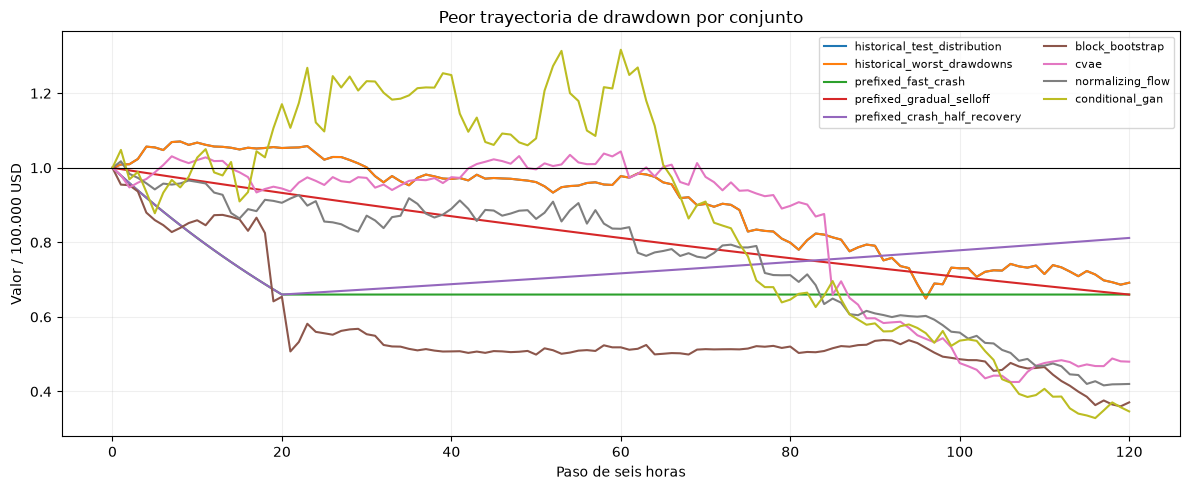

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, summary in report.scenarios.items():
    ax.plot(np.asarray(summary.worst_drawdown_value_path) / portfolio.config.initial_value, label=name)
ax.axhline(1.0, color='black', linewidth=0.8)
ax.set(title='Peor trayectoria de drawdown por conjunto', xlabel='Paso de seis horas', ylabel='Valor / 100.000 USD')
ax.legend(fontsize=8, ncol=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

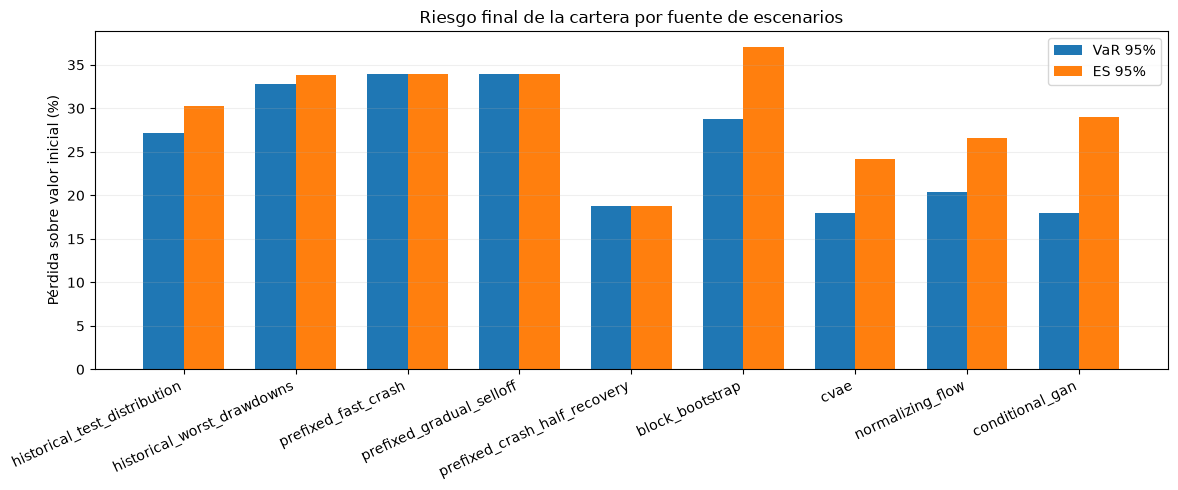

In [8]:
plot_risk = risk_table.loc[risk_table['confidence_level'].eq(0.95)].copy()
x = np.arange(len(plot_risk))
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 0.18, 100 * plot_risk['value_at_risk_fraction'], 0.36, label='VaR 95%')
ax.bar(x + 0.18, 100 * plot_risk['expected_shortfall_fraction'], 0.36, label='ES 95%')
ax.set_xticks(x, plot_risk['scenario_set'], rotation=25, ha='right')
ax.set(title='Riesgo final de la cartera por fuente de escenarios', ylabel='Pérdida sobre valor inicial (%)')
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Guardado reproducible

El JSON conserva configuración, métricas, metadatos y las peores trayectorias. Los dos CSV separan resumen de escenarios y comparación VaR/ES.

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
write_json_atomic(report.to_dict(), OUTPUT_DIR / 'stress_report.json')
write_csv_atomic(report.summary_records(), tuple(report.summary_records()[0]), OUTPUT_DIR / 'scenario_summary.csv')
write_csv_atomic(report.risk_records(), tuple(report.risk_records()[0]), OUTPUT_DIR / 'risk_comparison.csv')
print('Resultados guardados en:', OUTPUT_DIR.relative_to(ROOT))

Resultados guardados en: outputs/portfolio_stress_notebook


## Conclusión

La aplicación desacopla la valoración de cartera del generador: histórico, shocks, bootstrap y modelos neuronales consumen retornos logarítmicos con el mismo orden `[BTC, ETH]` y producen métricas comparables. El escenario prefijado BTC −30 % / ETH −40 % implica una pérdida terminal del 34 % para la cartera 60/40; la versión con recuperación parcial conserva el mismo drawdown máximo, pero reduce la pérdida final.

El bloque histórico completo puede usarse para cobertura fuera de muestra. Los peores episodios históricos y los shocks prefijados son ejercicios de severidad, no muestras aleatorias: sus percentiles describen esos conjuntos y no probabilidades verdaderas de mercado.

En esta ejecución se han incorporado los tres artefactos generativos. Al 95 %, el VaR/ES de CVAE (17,9 %/24,2 %), flow (20,3 %/26,5 %) y GAN (18,0 %/29,0 %) queda por debajo del histórico (27,1 %/30,2 %) y del block bootstrap (28,8 %/37,0 %). La ordenación cambia en la cola del 99 %: la GAN alcanza 35,9 %/42,8 %, por encima del histórico (32,5 %/33,5 %), aunque todavía por debajo del bootstrap (42,2 %/48,4 %). Por tanto, los generadores no ofrecen una estimación de cola intercambiable y la comparación debe conservar ambos niveles de confianza.

También aparece una señal que conviene vigilar: la GAN estima una pérdida terminal media de −14,1 % —es decir, una ganancia media— frente a −0,5 % en el test histórico. Ese sesgo central optimista convive con una cola extrema severa; los resultados son útiles como escenarios de estrés, pero no bastan por sí solos para afirmar que el modelo esté calibrado.